In [2]:
# import Path class from python, a tool for working with file system paths
# advantage of using Path is clearer when building paths 
# e.g. data_dir = Path("../data")
# file_name = "iris.csv"
# data_path = data_dir / file_name
from pathlib import Path 
import pandas as pd

# current folder, go up one directory, enter data folder, get iris csv
data_path = Path("../data/iris.csv")
df = pd.read_csv(data_path)

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# imports python's built in SQLite module
# after this import, python can create a db, connect to it
# read/write tables, and run SQL
import sqlite3

# conn opens a connection to a database file
# and importantly it creates it if the file does not exist
# so it made iris.sqlite
conn = sqlite3.connect("../data/iris.sqlite")
# this creates a sql table
df.to_sql("iris", conn, if_exists="replace", index=False)

# can also run sql in pandas using conn
pd.read_sql("select * from iris limit 5", conn)

# conn.close()




In [3]:
df.groupby("species").mean()

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.418,1.464,0.244
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


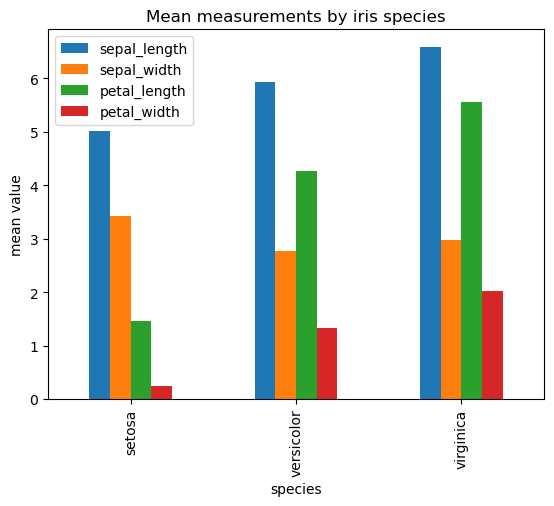

In [ ]:
import matplotlib.pyplot as plt
df.groupby("species").mean().plot(kind="bar")
plt.ylabel("mean value")
plt.title("Mean measurements by iris species")
plt.show()

In [8]:
# regress sepal length on petal length
import statsmodels.api as sm
X = df["petal_length"]
y = df["sepal_length"]
X = sm.add_constant(X) # adds intercept term to the model
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           sepal_length   R-squared:                       0.760
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     468.6
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           1.04e-47
Time:                        18:48:27   Log-Likelihood:                -77.020
No. Observations:                 150   AIC:                             158.0
Df Residuals:                     148   BIC:                             164.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            4.3056      0.078     54.895   